<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 118 · Reinforcement Learning Primer</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Reinforcement Learning Primer</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:740px;line-height:1.6">Meet the third paradigm: an agent that learns by acting and collecting rewards. We build a GridWorld from scratch, solve it with Q-learning, visualize the policy and value function it discovers, and use a multi-armed bandit on real ad data to make the exploration-vs-exploitation trade-off concrete, all in pure numpy, and heavily visual.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Reinforcement Learning: learning from consequences
Supervised learning needs labeled answers; unsupervised learning finds structure. **Reinforcement learning** needs neither: an **agent** learns by *acting* in an **environment** and collecting **rewards**, discovering good behavior through trial and error. This notebook builds a tiny GridWorld from scratch, teaches an agent to solve it with **Q-learning**, visualizes the **policy** and **value function** it learns, then uses a **multi-armed bandit** on real ad data to make the **exploration vs exploitation** trade-off concrete. Pure `numpy`, so every moving part is visible.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#4338ca"; DEEP="#3730a3"; LIGHT="#c7d2fe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#4338ca"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
rng = np.random.default_rng(118)

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 1 &#183; THE ENVIRONMENT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A world, states, actions, rewards</div>
<div style="color:#4a5578;margin-top:6px">Build a 5x5 GridWorld the agent must navigate.</div>
</div>

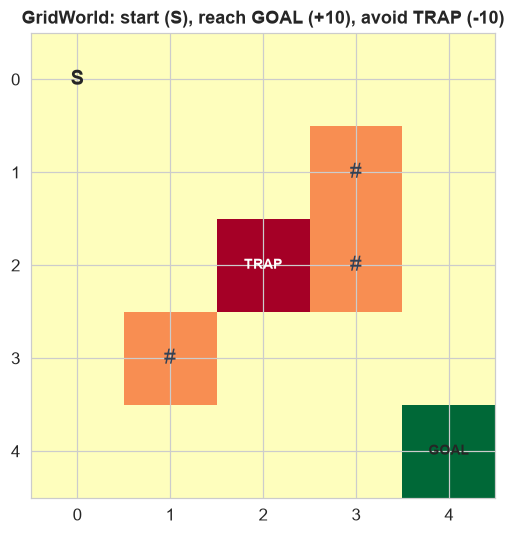

In [3]:
GRID = 5
start, goal, trap = (0,0), (4,4), (2,2)
walls = {(1,3),(2,3),(3,1)}
MOVES = {0:(-1,0), 1:(0,1), 2:(1,0), 3:(0,-1)}   # up, right, down, left
def step(rc, a):
    r,c = rc; dr,dc = MOVES[a]; nr,nc = r+dr, c+dc
    if nr<0 or nr>=GRID or nc<0 or nc>=GRID or (nr,nc) in walls: nr,nc = r,c   # blocked: stay put
    if (nr,nc)==goal: return (nr,nc), 10.0, True     # reach goal: big reward, episode ends
    if (nr,nc)==trap: return (nr,nc), -10.0, True    # fall in trap: big penalty, episode ends
    return (nr,nc), -0.1, False                       # every step costs a little (encourages short paths)
grid_img = np.zeros((GRID,GRID))
for w in walls: grid_img[w] = -0.5
grid_img[goal] = 1; grid_img[trap] = -1
fig, ax = plt.subplots(figsize=(5,5))
ax.imshow(grid_img, cmap='RdYlGn', vmin=-1, vmax=1)
ax.text(start[1],start[0],'S',ha='center',va='center',fontweight='bold',fontsize=13)
ax.text(goal[1],goal[0],'GOAL',ha='center',va='center',fontweight='bold',fontsize=9)
ax.text(trap[1],trap[0],'TRAP',ha='center',va='center',fontweight='bold',fontsize=9,color='white')
for w in walls: ax.text(w[1],w[0],'#',ha='center',va='center',fontsize=14,color='#334155')
ax.set(title='GridWorld: start (S), reach GOAL (+10), avoid TRAP (-10)', xticks=range(5), yticks=range(5)); plt.tight_layout(); plt.show()

**The RL vocabulary, made concrete.** The **agent** occupies a cell (its **state**). It picks one of four **actions** (move up/right/down/left), the **environment** returns the next state and a **reward**: +10 for reaching the goal, -10 for the trap, and -0.1 for every ordinary step (a gentle nudge toward short paths). One run from start to a terminal cell is an **episode**. Walls (#) block movement. Nobody tells the agent the right moves, it must discover them from rewards alone.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 2 &#183; RANDOM vs LEARNED</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Trial and error, then Q-learning</div>
<div style="color:#4a5578;margin-top:6px">A random agent flails; Q-learning improves episode by episode.</div>
</div>

random agent: average return = -10.28


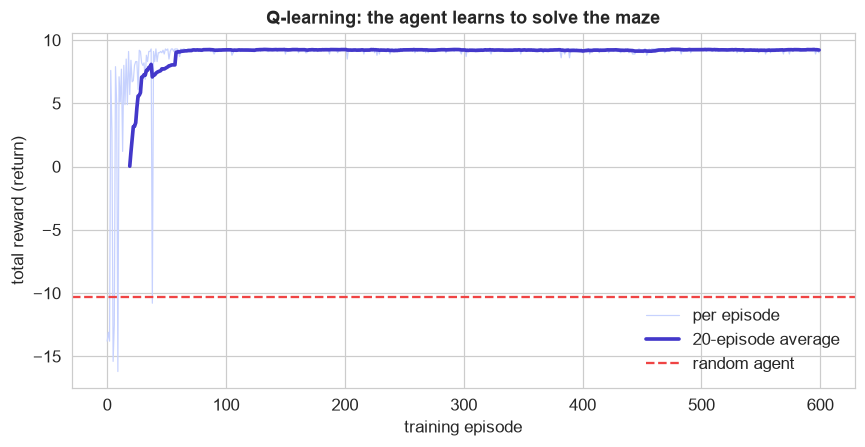

trained agent: average return = 9.30


In [4]:
def run_episode(policy, max_steps=100):
    s = start; total = 0.0
    for _ in range(max_steps):
        a = policy(s); s, r, done = step(s, a); total += r
        if done: break
    return total
random_scores = [run_episode(lambda s: rng.integers(4)) for _ in range(200)]
print('random agent: average return = %.2f' % np.mean(random_scores))
# ---- Q-learning ----
Q = np.zeros((GRID, GRID, 4)); alpha, gamma, eps = 0.1, 0.95, 0.1
curve = []
for ep in range(600):
    s = start; total = 0.0
    for _ in range(100):
        a = rng.integers(4) if rng.random() < eps else int(np.argmax(Q[s[0],s[1]]))
        s2, r, done = step(s, a); total += r
        best_next = 0.0 if done else np.max(Q[s2[0],s2[1]])
        Q[s[0],s[1],a] += alpha * (r + gamma*best_next - Q[s[0],s[1],a])   # the Q-learning update
        s = s2
        if done: break
    curve.append(total)
fig, ax = plt.subplots(figsize=(8,4.2))
roll = pd.Series(curve).rolling(20).mean()
ax.plot(curve, color=LIGHT, lw=0.8, label='per episode'); ax.plot(roll, color=EM, lw=2.4, label='20-episode average')
ax.axhline(np.mean(random_scores), color=RED, ls='--', label='random agent')
ax.set(xlabel='training episode', ylabel='total reward (return)', title='Q-learning: the agent learns to solve the maze'); ax.legend()
plt.tight_layout(); plt.show()
greedy = lambda s: int(np.argmax(Q[s[0],s[1]]))
print('trained agent: average return = %.2f' % np.mean([run_episode(greedy) for _ in range(200)]))

**The one equation that matters.** The agent keeps a **Q-table**, an estimate Q(state, action) of the total future reward for taking that action then acting well after. Each step nudges it toward reality with the **Q-learning update**: move Q(s,a) a little toward `reward + gamma * best next Q`. The **discount** gamma (0.95) makes near rewards count more than distant ones. A random agent averages a badly negative return (it wanders into the trap); after a few hundred episodes the learned agent reliably reaches the goal with a strongly positive return, having been *told* nothing, only rewarded.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 3 &#183; POLICY AND VALUE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">What did it actually learn?</div>
<div style="color:#4a5578;margin-top:6px">Two classic RL pictures: the policy and the value function.</div>
</div>

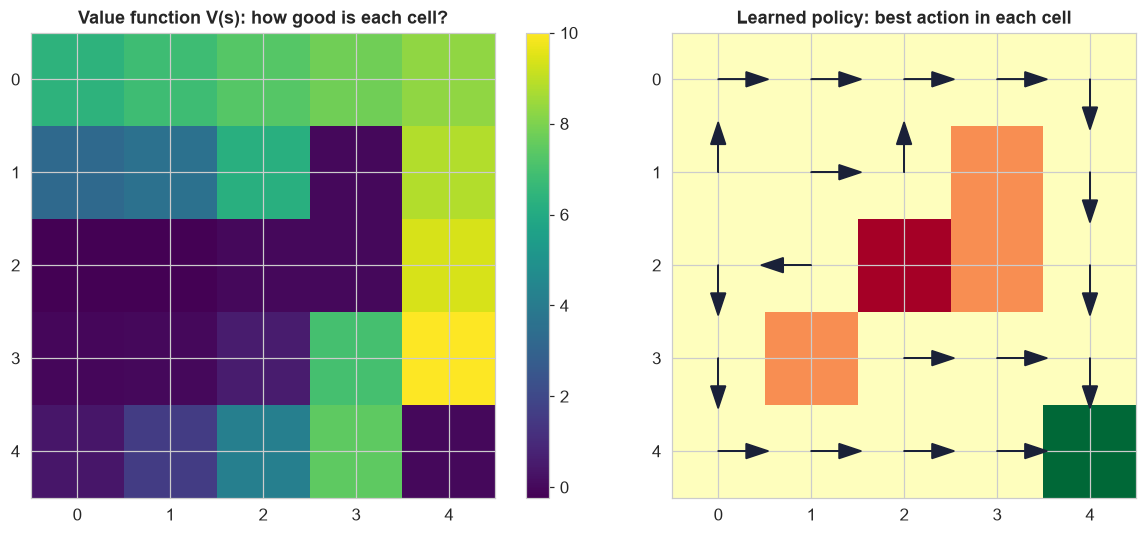

value at start = 6.38 (positive: the agent expects to win from here)


In [5]:
V = Q.max(axis=2)                          # state value = best action's Q
pi = Q.argmax(axis=2)                       # greedy policy = best action per state
fig, ax = plt.subplots(1, 2, figsize=(12,5))
im = ax[0].imshow(V, cmap='viridis'); plt.colorbar(im, ax=ax[0], fraction=0.046)
ax[0].set_title('Value function V(s): how good is each cell?')
ax[1].imshow(grid_img, cmap='RdYlGn', vmin=-1, vmax=1)
ARROW = {0:(0,-0.3),1:(0.3,0),2:(0,0.3),3:(-0.3,0)}
for r in range(GRID):
    for c in range(GRID):
        if (r,c) in walls or (r,c) in (goal,trap): continue
        dx,dy = ARROW[pi[r,c]]; ax[1].arrow(c,r,dx,dy, head_width=0.16, color='#1a2138')
ax[1].set_title('Learned policy: best action in each cell'); plt.tight_layout(); plt.show()
print('value at start = %.2f (positive: the agent expects to win from here)' % V[start])

**Two views of the solution.** The **value function** V(s) grades each cell by the best return achievable from it, notice how value rises smoothly toward the goal and craters near the trap. The **policy** is the agent's rule of behavior: in every cell, take the highest-Q action. Drawn as arrows, it forms a clear flow that steers around the trap and walls straight to the goal. Value answers 'how good is this state?'; policy answers 'what should I do here?', and Q-learning produced both from raw experience.

<div style="background:#eef6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">DEMO 4 &#183; EXPLORATION vs EXPLOITATION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The central dilemma, on real ad data</div>
<div style="color:#4a5578;margin-top:6px">A bandit must balance trying new options against milking the best known one.</div>
</div>

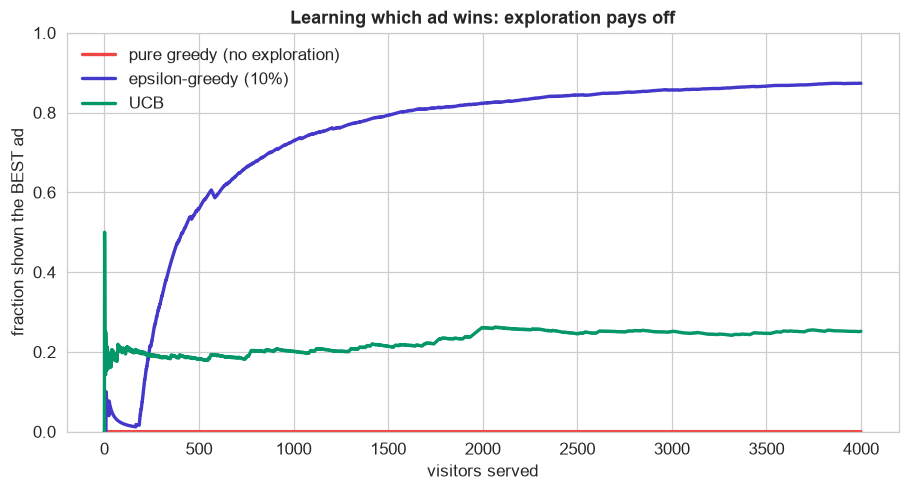

best ad is AD2 (true CTR 11.2%)
epsilon-greedy sent 82% of traffic to it and estimated its CTR at 11.4%


In [6]:
try: ads = pd.read_excel('../../data/ch118_bandit.xlsx', sheet_name='Data')
except FileNotFoundError: ads = pd.read_excel(BASE + 'ch118_bandit.xlsx', sheet_name='Data')
ctr = ads['true_ctr'].values; K = len(ctr); best = int(np.argmax(ctr)); T = 4000
def bandit(strategy, c=2.0):
    Q = np.zeros(K); N = np.zeros(K); opt = []
    for t in range(1, T+1):
        if strategy=='greedy': a = int(np.argmax(Q))
        elif strategy=='eps': a = rng.integers(K) if rng.random()<0.1 else int(np.argmax(Q))
        else: a = int(np.argmax(Q + c*np.sqrt(np.log(t)/(N+1e-9))))   # UCB
        reward = 1.0 if rng.random() < ctr[a] else 0.0
        N[a]+=1; Q[a]+= (reward-Q[a])/N[a]
        opt.append(N[best]/t)
    return np.array(opt), Q, N
fig, ax = plt.subplots(figsize=(8.4,4.6))
for strat,col,lab in [('greedy',RED,'pure greedy (no exploration)'),('eps',EM,'epsilon-greedy (10%)'),('ucb',GREEN,'UCB')]:
    opt,_,_ = bandit(strat); ax.plot(opt, color=col, lw=2.2, label=lab)
ax.set(xlabel='visitors served', ylabel='fraction shown the BEST ad', title='Learning which ad wins: exploration pays off'); ax.legend(); ax.set_ylim(0,1)
plt.tight_layout(); plt.show()
opt, Qhat, Nhat = bandit('eps')
print('best ad is %s (true CTR %.1f%%)' % (ads['ad_id'][best], ctr[best]*100))
print('epsilon-greedy sent %.0f%% of traffic to it and estimated its CTR at %.1f%%' % (Nhat[best]/T*100, Qhat[best]*100))

**Explore, or exploit?** An agent that only **exploits** (pure greedy) commits to whichever ad looked best after a few noisy clicks, and can lock onto a loser forever, it never gathers the evidence to know better. An agent that **explores** occasionally tries other ads, paying a small short-term cost to find the truly best one. **Epsilon-greedy** explores at random 10% of the time; **UCB** explores smartly, favoring options it is *uncertain* about. Both quickly concentrate traffic on the real winner (AD2). This exploration-exploitation balance is the beating heart of reinforcement learning, and of A/B testing, recommendation, and clinical-trial design.

## Reinforcement learning, in one view

- **Agent, environment, state, action, reward**: the agent acts, the environment responds with a reward and a new state.
- The goal is to maximize **cumulative discounted reward** (return), not to match any label.
- **Q-learning** learns an action-value table via one update rule; the greedy **policy** and the **value function** fall out of it.
- **Exploration vs exploitation** is the core dilemma: you must try new actions to learn, yet exploit what you know to win.
- RL is the third paradigm, no labels (supervised) and no fixed dataset (unsupervised), just **learning from consequences**.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>